This workbook focuses on the data transformation part of our project 

In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
#Loading the data into a dataframe
#Note we had to specify the semicolon after reading in the file because the dataset is seperated by that instaed of a comma

df = pd.read_csv("/Users/sa03/Phase-1-Portfolio-Project/data/dataset_Facebook.csv" , sep = ";")

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

In [123]:
df.isna().sum()

Page total likes                                                       0
Type                                                                   0
Category                                                               0
Post Month                                                             0
Post Weekday                                                           0
Post Hour                                                              0
Paid                                                                   1
Lifetime Post Total Reach                                              0
Lifetime Post Total Impressions                                        0
Lifetime Engaged Users                                                 0
Lifetime Post Consumers                                                0
Lifetime Post Consumptions                                             0
Lifetime Post Impressions by people who have liked your Page           0
Lifetime Post reach by people who like your Page   

We observe froom above that a few of our column has missing variables so lets work on solving those.

In [124]:
#Handling the missing values. 

df["Paid"] = df["Paid"].fillna(0)
df["like"] = df["like"].fillna(0)
df["share"] = df["share"].fillna(0)
df["comment"] = df["comment"].fillna(0)

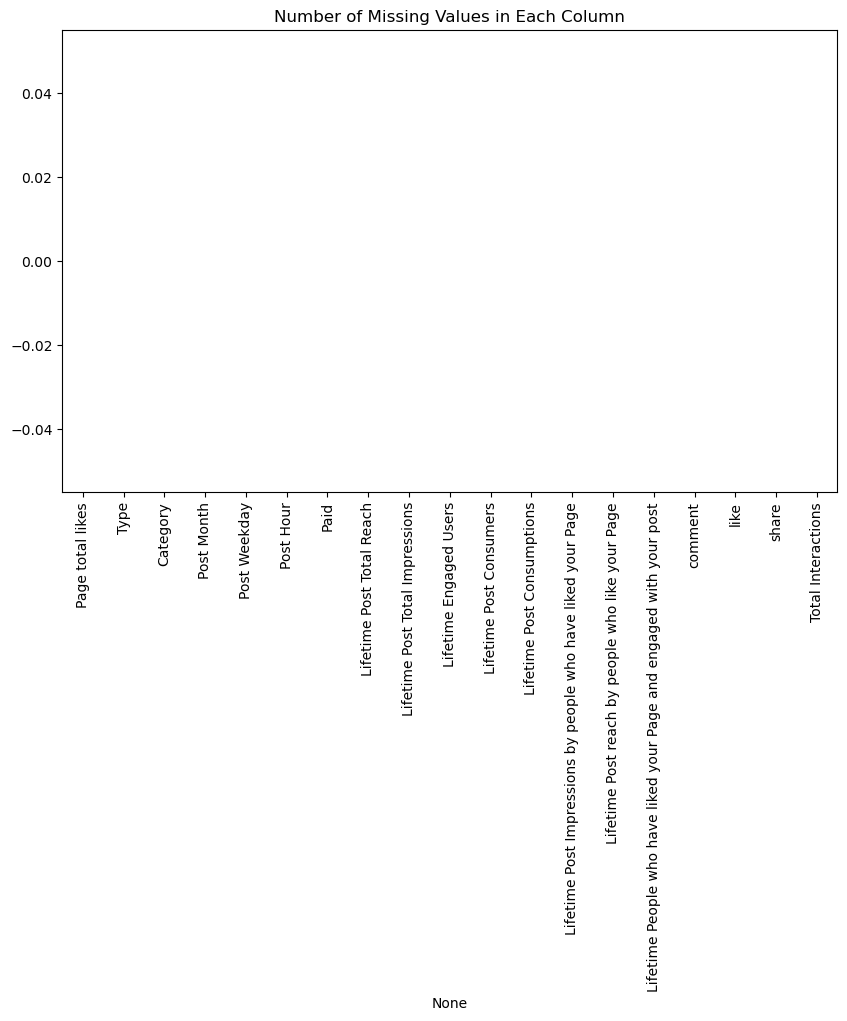

In [125]:
# Visualizing the number of missing values in each column
# Now we know that all the values have been dropped successfully.

plt.figure(figsize=(10,6))
sns.barplot(x=df.isna().sum().index, y=df.isna().sum().values)
plt.xticks(rotation=90)
plt.title("Number of Missing Values in Each Column")
plt.show()


In [126]:
#Fixing the data types of the columns.

df["Paid"] = df["Paid"].astype(int)
df["like"] = df["like"].astype(int)
df["share"] = df["share"].astype(int)
df["comment"] = df["comment"].astype(int)

Lets make some feature engineering and group a few bin categories

In [127]:
#Here we are grouping the types of posts into two categories: Visual and Text. This will help us to analyze the data better and to see if there is any difference in the engagement between the two types of posts.

df["Type_Grouped"] = df["Type"].replace({"Photo": "Visual", "Video": "Visual", "Link": "Text", "Status": "Text"})

In [128]:
#To make that we easily understand the posting time, we are going to create bins for them 
#We have created bins for morning, afternoon and evening these time bins.

def hour_to_period(h):
    if 5 <= h < 12:
        return "Morning"
    elif 12 <= h < 17:
        return "Afternoon"
    elif 17 <= h < 21:
        return "Evening"
    else:
        return "Night"
    
df["Post_Time_Period"] = df["Post Hour"].apply(hour_to_period)

Now lets drop columns that are components of the target variable which in our case is Total Interactions. If we leave them in, it will make our model useless for real prediction

In [129]:
#Now we are going to drop the columns that are not needed for our analysis. These columns are the ones that are related to our target variable. 

leakage_cols = ["like", "share", "comment","Lifetime Post Total Reach",
                "Lifetime Post Total Impressions","Lifetime Engaged Users",
                "Lifetime Post Consumers","Lifetime Post Consumptions",
                "Lifetime Post Impressions by people who have liked your Page",
                "Lifetime Post reach by people who like your Page",
                "Lifetime People who have liked your Page and engaged with your post"]

df = df.drop(columns=leakage_cols)

In [130]:
#Lets look at the first 5 rows of the dataframe to see the changes we have made.

df.head()

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Total Interactions,Type_Grouped,Post_Time_Period
0,139441,Photo,2,12,4,3,0,100,Visual,Night
1,139441,Status,2,12,3,10,0,164,Text,Morning
2,139441,Photo,3,12,3,3,0,80,Visual,Night
3,139441,Photo,2,12,2,10,1,1777,Visual,Morning
4,139441,Photo,2,12,2,3,0,393,Visual,Night


### Log-transform the target
We need to do this because we observed from our explore stage that our target variable(Total interactions) is postively skewed and the log will make it adjusted for our model

In [131]:
df['Log_Interactions'] = np.log1p(df['Total Interactions'])

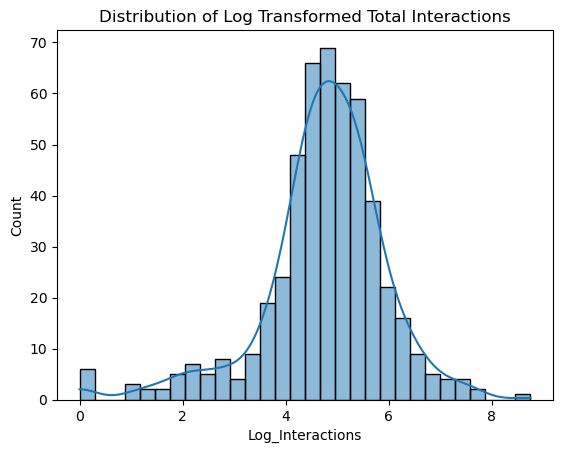

np.float64(-1.0119439732005284)

In [132]:
#Lets see how our target is looking after the log transformation.

sns.histplot(df["Log_Interactions"],kde = True)
plt.title('Distribution of Log Transformed Total Interactions')
plt.show()

df["Log_Interactions"].skew()

We can see that our target looks much better with the log transformation and the skew has also adjusted to a somewhat normal distribution.

In [133]:
#Let encode the categorical variables using one hot encoding.
#This converts our categorical colums to numeric dummy variables and the last part helps us to avoid multicollinearity.

df = pd.get_dummies(df, columns=["Type_Grouped", "Category","Post_Time_Period"], drop_first=True)

df.head()

,Page total likes,Type,Post Month,Post Weekday,Post Hour,Paid,Total Interactions,Log_Interactions,Type_Grouped_Visual,Category_2,Category_3,Post_Time_Period_Evening,Post_Time_Period_Morning,Post_Time_Period_Night
0,139441,Photo,12,4,3,0,100,4.615121,True,True,False,False,False,True
1,139441,Status,12,3,10,0,164,5.105945,False,True,False,False,True,False
2,139441,Photo,12,3,3,0,80,4.394449,True,False,True,False,False,True
3,139441,Photo,12,2,10,1,1777,7.483244,True,True,False,False,True,False
4,139441,Photo,12,2,3,0,393,5.976351,True,True,False,False,False,True


Building our feature matrix

In [134]:
feature_cols = [col for col in df.columns if col not in ["Total Interactions", "Log_Interactions","Type"]]

X = df[feature_cols]
y = df["Log_Interactions"]

In [135]:
# Saving our cleaned data to a new csv file for future use in the modeling phase.

datapath = "/Users/sa03/Phase-1-Portfolio-Project/data"
df.to_csv('/Users/sa03/Phase-1-Portfolio-Project/data/facebook_data_cleaned.csv')